# Tech Challenge — Fase 1
## Sistema Inteligente de Suporte ao Diagnóstico — Hospital Universitário
### Dataset: Breast Cancer Wisconsin (Diagnóstico de Câncer de Mama)

Este notebook implementa um sistema de classificação de exames médicos utilizando Machine Learning
para auxiliar médicos e equipes clínicas na análise inicial de resultados e apoio ao diagnóstico.

---
## 1. Importação das Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Explicabilidade
import shap

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


c:\Users\mismo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn shap

You should consider upgrading via the 'c:\Users\mismo\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


---
## 2. Carregamento e Exploração dos Dados (EDA)

In [3]:
# Carregando o dataset Breast Cancer Wisconsin via scikit-learn
# Mesmo dataset disponível em: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnostico'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print(f'Shape do dataset: {df.shape}')
print(f'Total de features: {len(data.feature_names)}')
df.head()

Shape do dataset: (569, 32)
Total de features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Maligno


In [4]:
# Informações gerais
print('=== INFORMAÇÕES DO DATASET ===')
print(f'Total de amostras: {len(df)}')
print(f'\nDistribuição dos diagnósticos:')
print(df['diagnostico'].value_counts())
print(f'\nPorcentagem:')
print(df['diagnostico'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== INFORMAÇÕES DO DATASET ===
Total de amostras: 569

Distribuição dos diagnósticos:
diagnostico
Benigno    357
Maligno    212
Name: count, dtype: int64

Porcentagem:
diagnostico
Benigno    62.7%
Maligno    37.3%
Name: proportion, dtype: object


In [5]:
# Estatísticas descritivas das primeiras features
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df[list(data.feature_names[:6])].describe().round(2)

=== ESTATÍSTICAS DESCRITIVAS ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10
std,3.52,4.30,24.30,351.91,0.01,0.05
min,6.98,9.71,43.79,143.50,0.05,0.02
25%,11.70,16.17,75.17,420.30,0.09,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09
75%,15.78,21.80,104.10,782.70,0.11,0.13
max,28.11,39.28,188.50,2501.00,0.16,0.35


In [6]:
# Verificando valores ausentes e tipos de dados
print('=== QUALIDADE DOS DADOS ===')
print(f'Valores ausentes: {df.isnull().sum().sum()}')
print(f'Duplicatas: {df.duplicated().sum()}')
print('\nO dataset está completo e sem duplicatas — nenhuma limpeza necessária.')

=== QUALIDADE DOS DADOS ===
Valores ausentes: 0
Duplicatas: 0

O dataset está completo e sem duplicatas — nenhuma limpeza necessária.


### 2.1 Visualizações

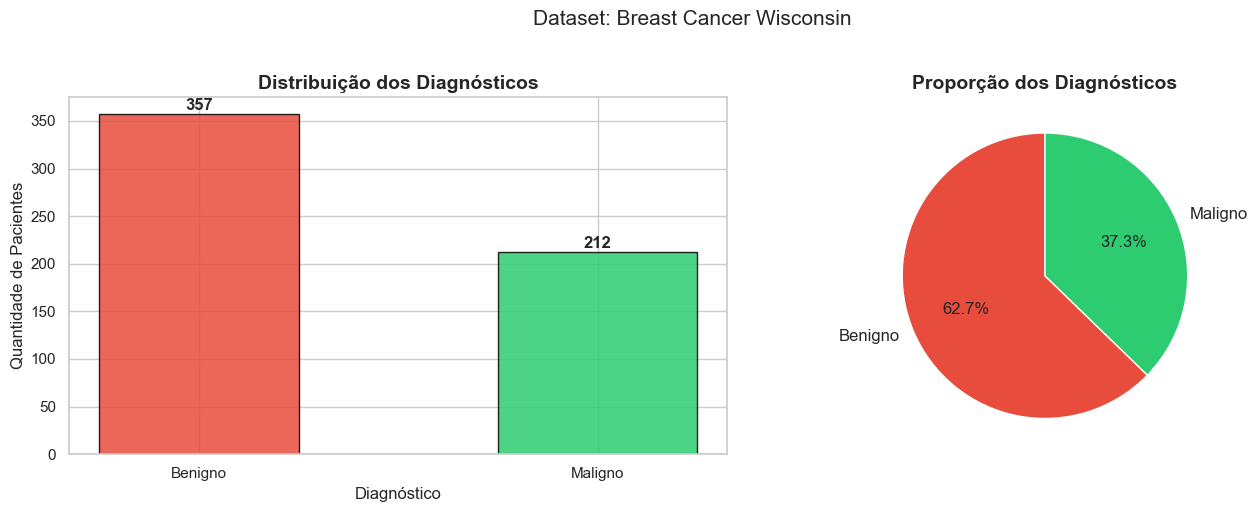

In [7]:
# Distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem = df['diagnostico'].value_counts()
cores = ['#e74c3c', '#2ecc71']

axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title('Distribuição dos Diagnósticos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Quantidade de Pacientes')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(contagem.values, labels=contagem.index, colors=cores,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção dos Diagnósticos', fontsize=14, fontweight='bold')

plt.suptitle('Dataset: Breast Cancer Wisconsin', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('distribuicao_diagnosticos.png', dpi=150, bbox_inches='tight')
plt.show()

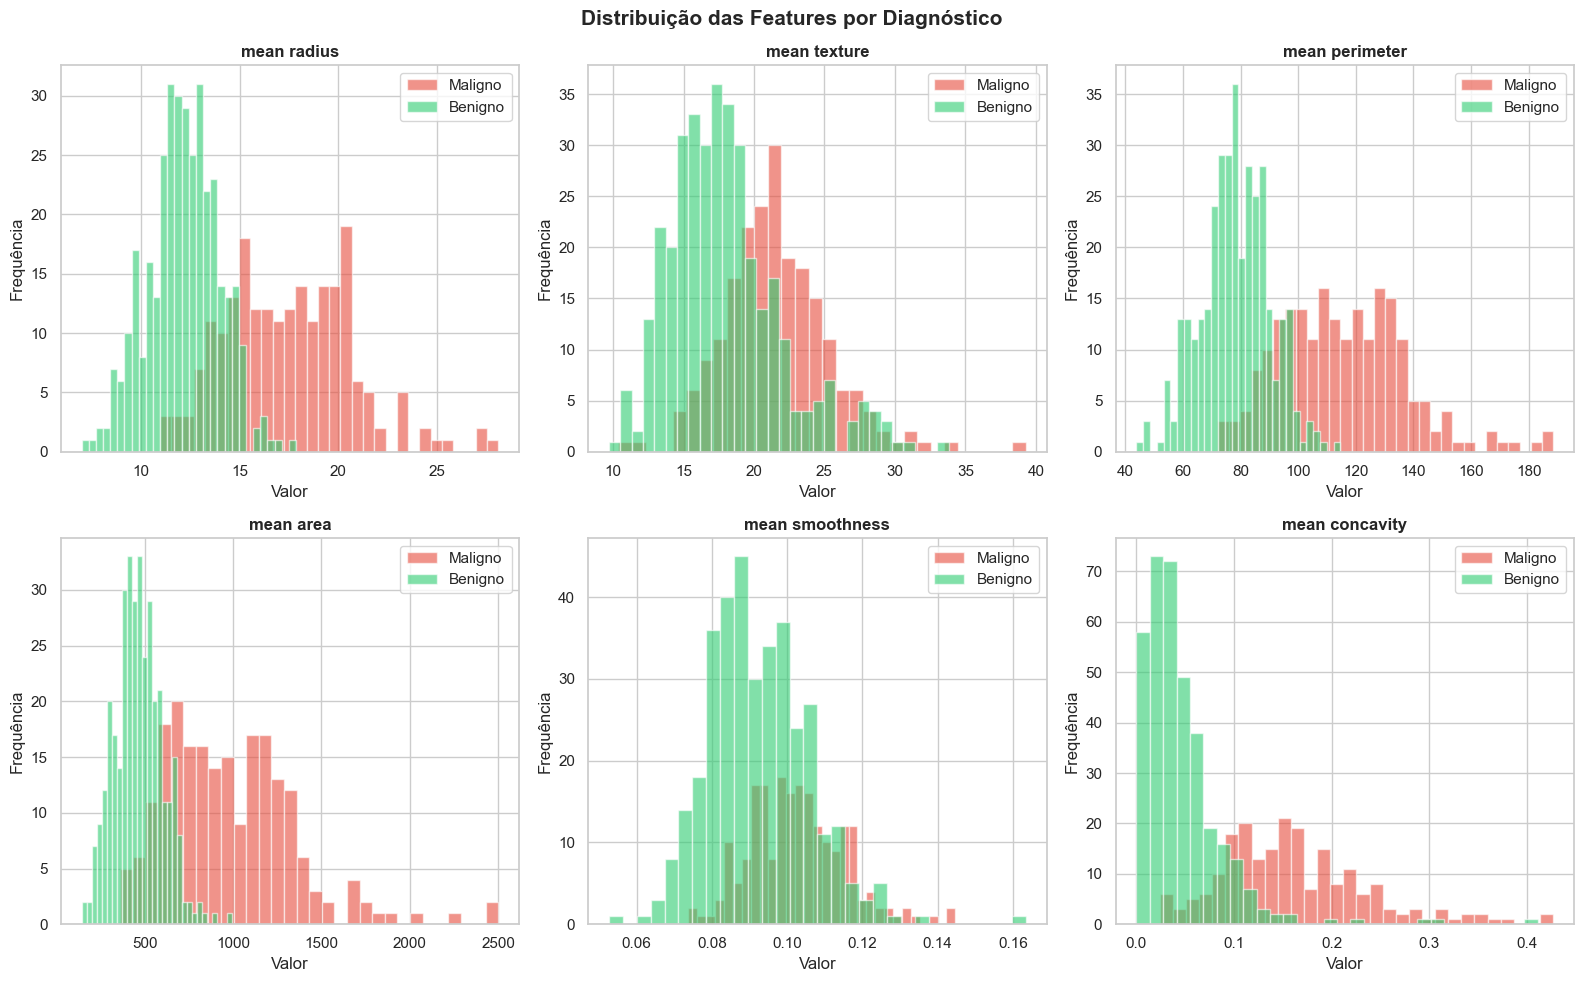


Observação: Features como mean radius e mean perimeter mostram separação
clara entre tumores malignos e benignos — indicando alto poder preditivo.


In [8]:
# Distribuição das features por diagnóstico
features_plot = ['mean radius', 'mean texture', 'mean perimeter',
                 'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_plot):
    for diag, cor in zip(['Maligno', 'Benigno'], ['#e74c3c', '#2ecc71']):
        subset = df[df['diagnostico'] == diag][feature]
        axes[i].hist(subset, bins=30, alpha=0.6, color=cor, label=diag, edgecolor='white')
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Distribuição das Features por Diagnóstico', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservação: Features como mean radius e mean perimeter mostram separação')
print('clara entre tumores malignos e benignos — indicando alto poder preditivo.')

### 2.2 Análise de Correlação

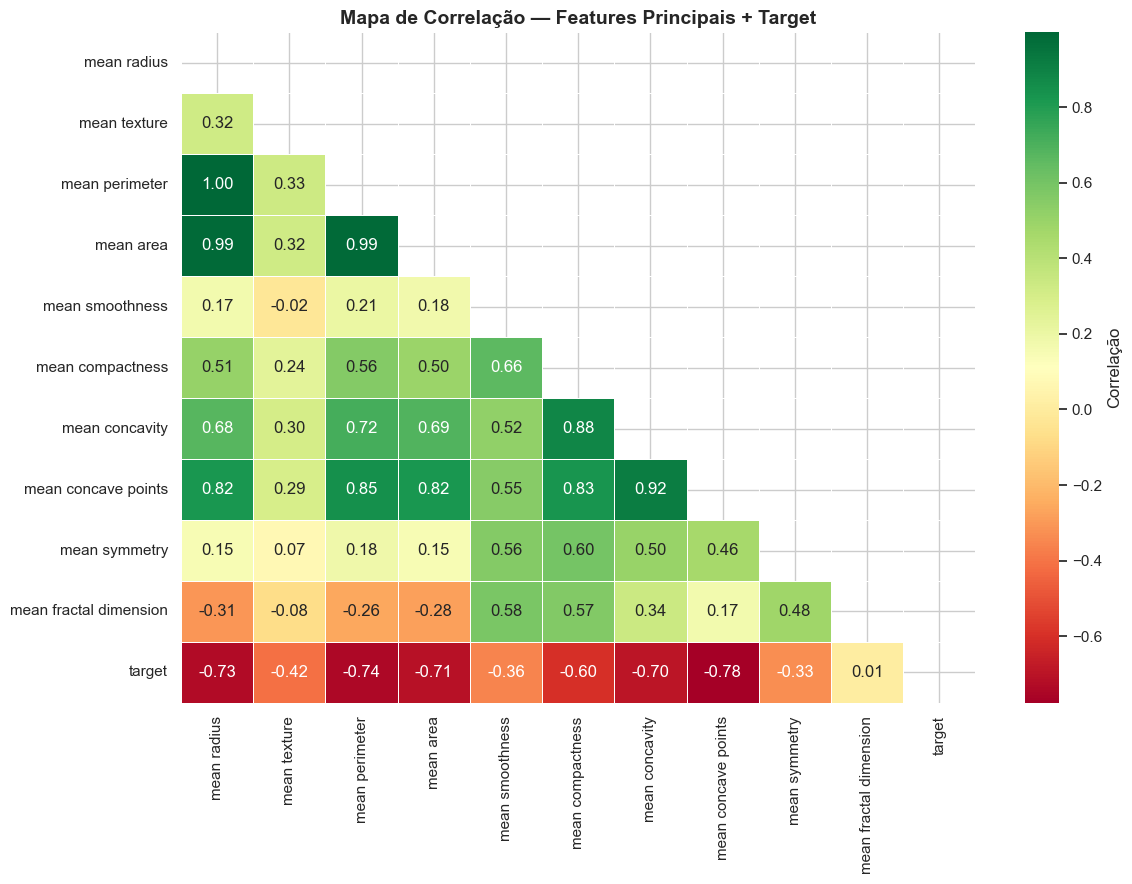

Top 5 features mais correlacionadas com o diagnóstico:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
dtype: float64


In [9]:
# Mapa de correlação
features_corr = list(data.feature_names[:10]) + ['target']
corr_matrix = df[features_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, cbar_kws={'label': 'Correlação'})
plt.title('Mapa de Correlação — Features Principais + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features correlacionadas com o target
corr_target = df[list(data.feature_names)].corrwith(df['target']).abs().sort_values(ascending=False)
print('Top 5 features mais correlacionadas com o diagnóstico:')
print(corr_target.head())

---
## 3. Pré-processamento dos Dados

In [10]:
# Separando features e target
X = df[list(data.feature_names)]
y = df['target']

# ── Divisão em 3 conjuntos: Treino (70%) / Validação (15%) / Teste (15%) ──
#
# Por que 3 conjuntos?
# - TREINO:    o modelo aprende com esses dados
# - VALIDAÇÃO: usamos para ajustar e comparar modelos durante o desenvolvimento
# - TESTE:     usado UMA ÚNICA VEZ no final, para avaliação final imparcial

# Passo 1: separa 15% para teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Passo 2: do restante (85%), separa ~17.6% para validação → resulta em ~15% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print('=== DIVISÃO DOS DADOS ===')
print(f'Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Total:     {len(X)} amostras')

=== DIVISÃO DOS DADOS ===
Treino:    397 amostras (70%)
Validação: 86 amostras (15%)
Teste:     86 amostras (15%)
Total:     569 amostras


In [11]:
# Normalização — fit APENAS no treino, transform nos demais
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('Normalização aplicada com StandardScaler.')
print('Regra importante: o scaler aprende apenas com os dados de TREINO.')
print('Validação e Teste apenas recebem a transformação — sem vazar informação.')

Normalização aplicada com StandardScaler.
Regra importante: o scaler aprende apenas com os dados de TREINO.
Validação e Teste apenas recebem a transformação — sem vazar informação.


---
## 4. Modelagem e Validação

### 4.1 Modelo 1: Regressão Logística

In [12]:
# Treinamento
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# Avaliação na validação (para comparar modelos e ajustar)
y_pred_lr_val = lr.predict(X_val_s)

print('=== REGRESSÃO LOGÍSTICA — Conjunto de Validação ===')
print(f'Acurácia:          {accuracy_score(y_val, y_pred_lr_val):.4f}')
print(f'Recall (Maligno):  {recall_score(y_val, y_pred_lr_val, pos_label=0):.4f}')
print(f'F1-Score (Maligno):{f1_score(y_val, y_pred_lr_val, pos_label=0):.4f}')

=== REGRESSÃO LOGÍSTICA — Conjunto de Validação ===
Acurácia:          1.0000
Recall (Maligno):  1.0000
F1-Score (Maligno):1.0000


### 4.2 Modelo 2: Árvore de Decisão

In [13]:
# Treinamento
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Avaliação na validação
y_pred_dt_val = dt.predict(X_val)

print('=== ÁRVORE DE DECISÃO — Conjunto de Validação ===')
print(f'Acurácia:          {accuracy_score(y_val, y_pred_dt_val):.4f}')
print(f'Recall (Maligno):  {recall_score(y_val, y_pred_dt_val, pos_label=0):.4f}')
print(f'F1-Score (Maligno):{f1_score(y_val, y_pred_dt_val, pos_label=0):.4f}')

=== ÁRVORE DE DECISÃO — Conjunto de Validação ===
Acurácia:          0.9651
Recall (Maligno):  0.9688
F1-Score (Maligno):0.9538


In [14]:
# Comparação na validação — escolhemos o melhor modelo aqui
print('=== COMPARAÇÃO NA VALIDAÇÃO ===')
comparacao_val = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia':          [accuracy_score(y_val, y_pred_lr_val), accuracy_score(y_val, y_pred_dt_val)],
    'Recall (Maligno)':  [recall_score(y_val, y_pred_lr_val, pos_label=0), recall_score(y_val, y_pred_dt_val, pos_label=0)],
    'F1-Score (Maligno)':[f1_score(y_val, y_pred_lr_val, pos_label=0), f1_score(y_val, y_pred_dt_val, pos_label=0)],
}).set_index('Modelo').round(4)

print(comparacao_val.to_string())
print('\n→ O modelo com maior Recall na validação será avaliado no conjunto de Teste.')

=== COMPARAÇÃO NA VALIDAÇÃO ===
                     Acurácia  Recall (Maligno)  F1-Score (Maligno)
Modelo                                                             
Regressão Logística    1.0000            1.0000              1.0000
Árvore de Decisão      0.9651            0.9688              0.9538

→ O modelo com maior Recall na validação será avaliado no conjunto de Teste.


---
## 5. Avaliação Final — Conjunto de Teste

In [15]:
# Avaliação FINAL dos dois modelos no conjunto de Teste
# O teste é usado apenas uma vez — aqui — para medir performance real
y_pred_lr_test = lr.predict(X_test_s)
y_pred_dt_test = dt.predict(X_test)

print('=== REGRESSÃO LOGÍSTICA — Conjunto de Teste (avaliação final) ===')
print(classification_report(y_test, y_pred_lr_test, target_names=['Maligno', 'Benigno']))

print('=== ÁRVORE DE DECISÃO — Conjunto de Teste (avaliação final) ===')
print(classification_report(y_test, y_pred_dt_test, target_names=['Maligno', 'Benigno']))

=== REGRESSÃO LOGÍSTICA — Conjunto de Teste (avaliação final) ===
              precision    recall  f1-score   support

     Maligno       0.94      0.97      0.95        32
     Benigno       0.98      0.96      0.97        54

    accuracy                           0.97        86
   macro avg       0.96      0.97      0.96        86
weighted avg       0.97      0.97      0.97        86

=== ÁRVORE DE DECISÃO — Conjunto de Teste (avaliação final) ===
              precision    recall  f1-score   support

     Maligno       0.88      0.94      0.91        32
     Benigno       0.96      0.93      0.94        54

    accuracy                           0.93        86
   macro avg       0.92      0.93      0.93        86
weighted avg       0.93      0.93      0.93        86



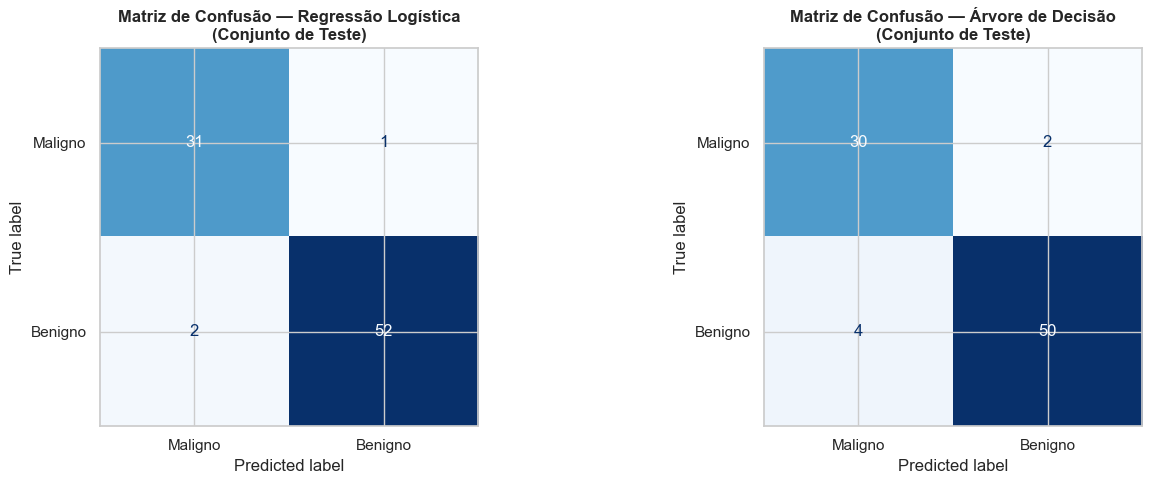

In [16]:
# Matrizes de confusão — Teste
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr_test, y_pred_dt_test],
    ['Regressão Logística', 'Árvore de Decisão']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno', 'Benigno'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão — {titulo}\n(Conjunto de Teste)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

=== RESULTADO FINAL — CONJUNTO DE TESTE ===
                     Acurácia  Recall (Maligno)  F1-Score (Maligno)
Modelo                                                             
Regressão Logística    0.9651            0.9688              0.9538
Árvore de Decisão      0.9302            0.9375              0.9091


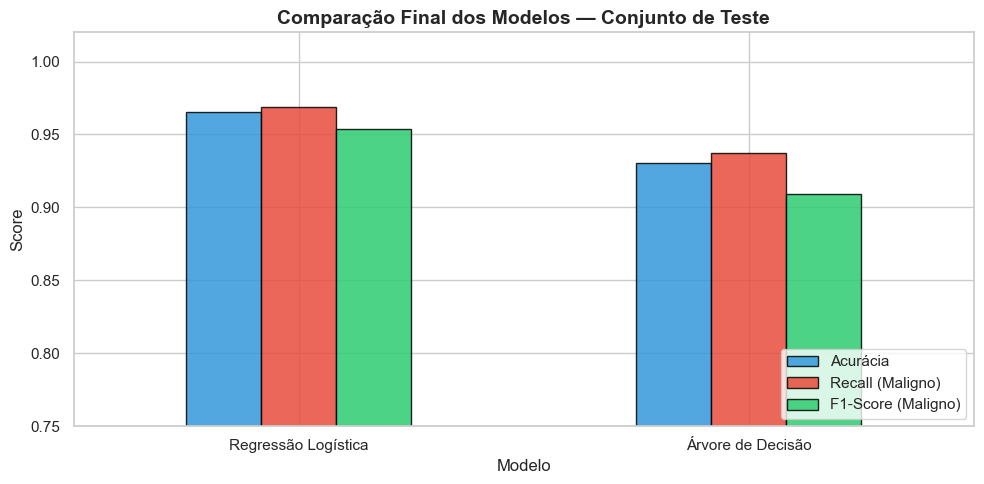


💡 Por que Recall é a métrica prioritária?
Um falso negativo (maligno classificado como benigno) pode atrasar
o tratamento e colocar a vida do paciente em risco.
Por isso priorizamos maximizar o Recall da classe Maligno.


In [17]:
# Tabela e gráfico comparativo final
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia':          [accuracy_score(y_test, y_pred_lr_test), accuracy_score(y_test, y_pred_dt_test)],
    'Recall (Maligno)':  [recall_score(y_test, y_pred_lr_test, pos_label=0), recall_score(y_test, y_pred_dt_test, pos_label=0)],
    'F1-Score (Maligno)':[f1_score(y_test, y_pred_lr_test, pos_label=0), f1_score(y_test, y_pred_dt_test, pos_label=0)],
}).set_index('Modelo').round(4)

print('=== RESULTADO FINAL — CONJUNTO DE TESTE ===')
print(resultados.to_string())

resultados.plot(kind='bar', figsize=(10, 5),
                color=['#3498db', '#e74c3c', '#2ecc71'],
                edgecolor='black', alpha=0.85)
plt.title('Comparação Final dos Modelos — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.75, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Por que Recall é a métrica prioritária?')
print('Um falso negativo (maligno classificado como benigno) pode atrasar')
print('o tratamento e colocar a vida do paciente em risco.')
print('Por isso priorizamos maximizar o Recall da classe Maligno.')

---
## 6. Explicabilidade

### 6.1 Feature Importance — Árvore de Decisão

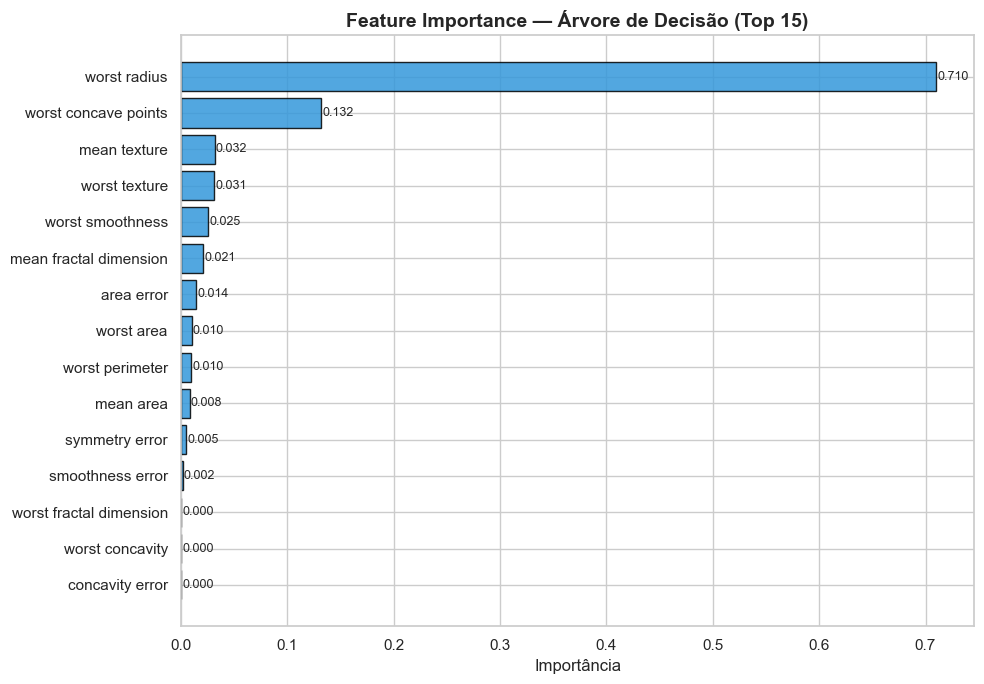

Feature mais importante: worst radius (0.710)


In [18]:
importances = pd.Series(dt.feature_importances_, index=data.feature_names)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(importances.index, importances.values,
                color='#3498db', edgecolor='black', alpha=0.85)
plt.xlabel('Importância')
plt.title('Feature Importance — Árvore de Decisão (Top 15)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, importances.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Feature mais importante: {importances.idxmax()} ({importances.max():.3f})')

### 6.2 SHAP — Regressão Logística

Calculando SHAP values...


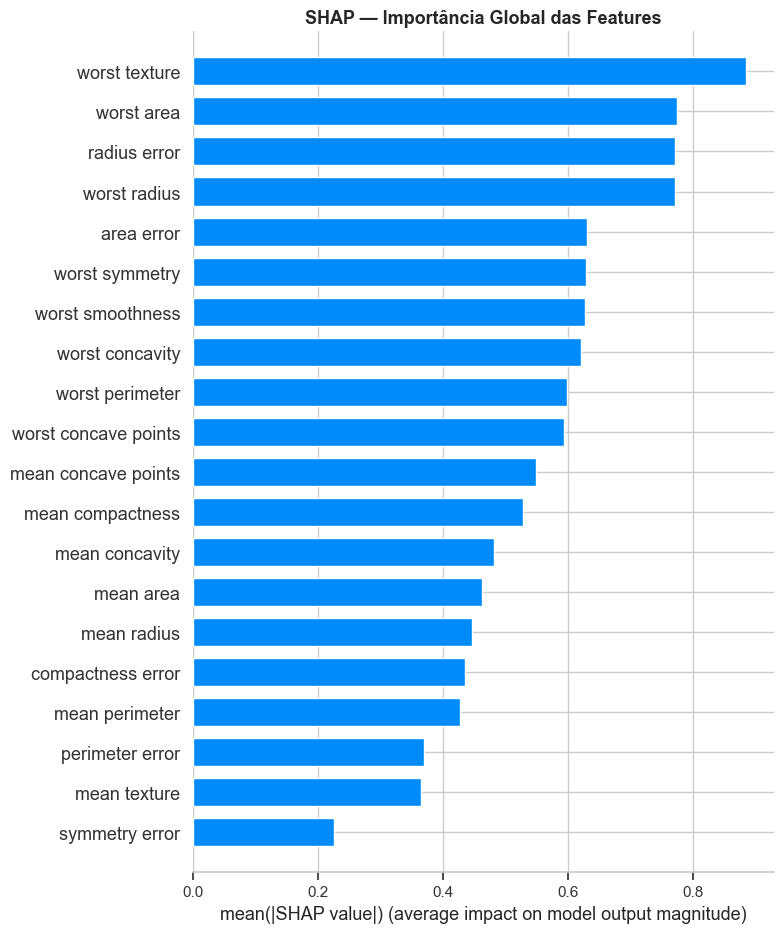

In [19]:
print('Calculando SHAP values...')
explainer  = shap.LinearExplainer(lr, X_train_s)
shap_values = explainer.shap_values(X_test_s)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=list(data.feature_names),
                  plot_type='bar', show=False)
plt.title('SHAP — Importância Global das Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

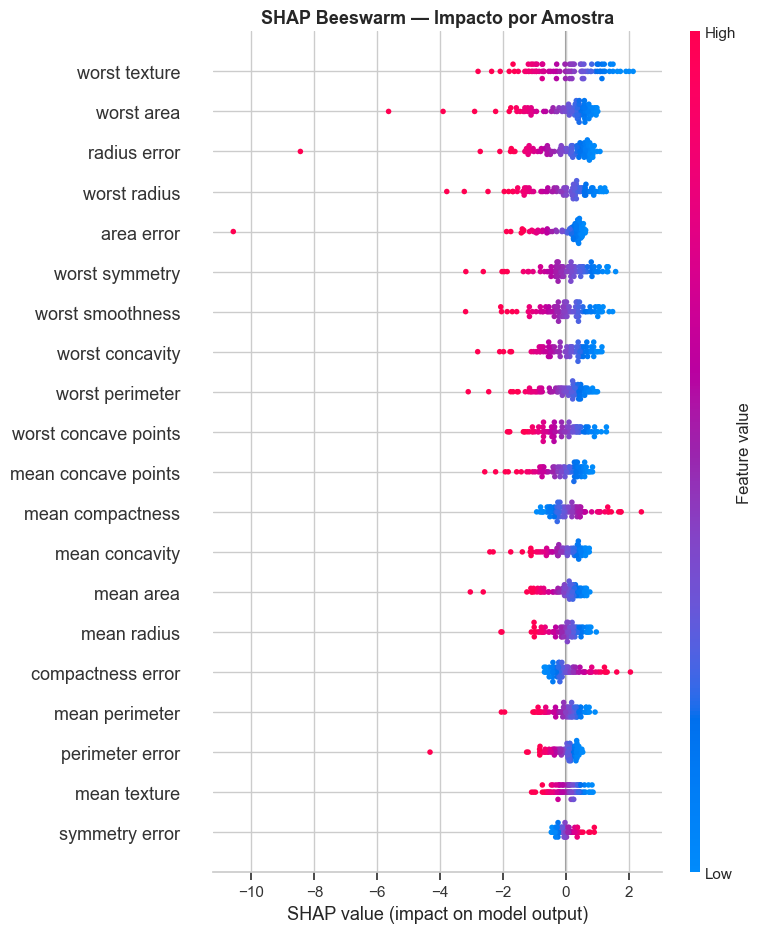


Interpretação:
- Valores positivos → aumentam probabilidade de Benigno
- Valores negativos → aumentam probabilidade de Maligno
- Vermelho = valor alto da feature | Azul = valor baixo


In [20]:
shap.summary_plot(shap_values, X_test,
                  feature_names=list(data.feature_names), show=False)
plt.title('SHAP Beeswarm — Impacto por Amostra', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretação:')
print('- Valores positivos → aumentam probabilidade de Benigno')
print('- Valores negativos → aumentam probabilidade de Maligno')
print('- Vermelho = valor alto da feature | Azul = valor baixo')

---
## 7. Discussão Crítica

In [21]:
print("""
=================================================================
              DISCUSSÃO CRÍTICA DOS RESULTADOS
=================================================================

1. SOBRE OS TRÊS CONJUNTOS
   A divisão treino/validação/teste é uma boa prática fundamental.
   O conjunto de validação permite comparar modelos durante o
   desenvolvimento sem contaminar a avaliação final. O teste é
   usado uma única vez, simulando dados que o modelo nunca viu.

2. ESCOLHA DA MÉTRICA PRINCIPAL
   O Recall da classe Maligno foi priorizado porque um falso
   negativo (dizer que um tumor é benigno quando é maligno) tem
   consequências muito mais graves que um falso positivo.
   Em diagnóstico oncológico, é preferível investigar mais
   do que deixar um caso maligno passar despercebido.

3. INTERPRETAÇÃO DO SHAP
   Features como 'worst concave points' e 'worst perimeter'
   aparecem como as mais determinantes — alinhado com o
   conhecimento clínico: tumores malignos tendem a ter bordas
   irregulares e núcleos maiores.

4. PODE SER USADO NA PRÁTICA?
   ✓ Como ferramenta de triagem e apoio à decisão médica
   ✓ Para priorizar casos urgentes em filas de espera
   ✗ Nunca como substituto do julgamento clínico
   ✗ Precisa de validação externa antes de implantação

5. LIMITAÇÕES
   - Dataset pequeno (569 amostras) e de fonte única
   - Não inclui histórico clínico ou dados temporais
   - Requer auditoria regular para detectar viés

=================================================================
   O MÉDICO SEMPRE DEVE TER A PALAVRA FINAL NO DIAGNÓSTICO.
=================================================================
""")


              DISCUSSÃO CRÍTICA DOS RESULTADOS

1. SOBRE OS TRÊS CONJUNTOS
   A divisão treino/validação/teste é uma boa prática fundamental.
   O conjunto de validação permite comparar modelos durante o
   desenvolvimento sem contaminar a avaliação final. O teste é
   usado uma única vez, simulando dados que o modelo nunca viu.

2. ESCOLHA DA MÉTRICA PRINCIPAL
   O Recall da classe Maligno foi priorizado porque um falso
   negativo (dizer que um tumor é benigno quando é maligno) tem
   consequências muito mais graves que um falso positivo.
   Em diagnóstico oncológico, é preferível investigar mais
   do que deixar um caso maligno passar despercebido.

3. INTERPRETAÇÃO DO SHAP
   Features como 'worst concave points' e 'worst perimeter'
   aparecem como as mais determinantes — alinhado com o
   conhecimento clínico: tumores malignos tendem a ter bordas
   irregulares e núcleos maiores.

4. PODE SER USADO NA PRÁTICA?
   ✓ Como ferramenta de triagem e apoio à decisão médica
   ✓ Para pri

---
## 8. Arquivos Gerados

| Arquivo | Descrição |
|---|---|
| `distribuicao_diagnosticos.png` | Distribuição Maligno vs Benigno |
| `distribuicao_features.png` | Histogramas das features principais |
| `correlacao.png` | Mapa de calor de correlação |
| `matrizes_confusao.png` | Matrizes de confusão — Teste |
| `comparacao_modelos.png` | Comparação de métricas — Teste |
| `feature_importance.png` | Feature Importance (Árvore) |
| `shap_summary.png` | SHAP global (barras) |
| `shap_beeswarm.png` | SHAP por amostra (beeswarm) |